# LightGBM Classifier - PS-S06E09: Electric Vehicle Purchases

This notebook trains a **LightGBM Classifier** model for Kaggle Playground Series Season 6 Episode 9, predicting the binary target `Will_Buy_EV` (`Yes` / `No`).

Key features:
* **Shared Utilities**: Leverages `ExperimentSetup`, `FeatureFactory`, and `ModelVisualizer`.
* **SQLite-Backed Optuna Persistence**: Hyperparameters tuned via Optuna with persistent SQLite storage (`lgbm_study.db`).
* **Fold Cache Pattern**: Features engineered once per fold and cached for fast Optuna evaluation.
* **Multi-Seed Ensembling**: Models evaluated across 5 stratified folds and multiple random seeds.
* **Prediction Export**: Probabilities saved for downstream model ensembling and blending.

## 1. Setup & Imports

In [1]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

from ps_s06e09_experiment_setup import ExperimentSetup
from ps_s06e09_feature_engineering import FeatureFactory
from ps_s06e09_model_visualizer import ModelVisualizer

# --- Notebook settings
warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
setup = ExperimentSetup(
    model_name='LightGBM',
    use_gpu=False,
    perform_optuna_tuning=True
)

seed = setup.set_seeds()
setup.configure_pandas()
setup.suppress_warnings()

TARGET = 'Will_Buy_EV'

Random seed set to: 10301
Warnings suppressed.


## 2. Load Datasets

In [3]:
training_df = setup.read_dataset('training')
train_ids = training_df['id'].copy()

test_df = setup.read_dataset('test')
test_ids = test_df['id'].copy()

TRAINING DATASET

   id  Age  Annual_Income_USD  Daily_Commute_km  Number_of_Cars_Owned  \
0   0   66         92,887.000            23.400                     2   
1   1   38         30,000.000             5.000                     1   
2   2   26         94,389.000            36.800                     1   
3   3   66         73,580.000            23.700                     2   
4   4   54         57,898.000            50.800                     1   

   Charging_Stations_Near_Home  Charging_Stations_Near_Work  \
0                            3                            7   
1                            2                            2   
2                            8                           15   
3                            6                            9   
4                            2                            3   

   Environmental_Concern_Level  Gender City_Type Current_Car_Type  \
0                        1.000    Male  Suburban            Sedan   
1                        4

## 3. Feature Engineering

In [4]:
fe_strategies = [
    'encoding',
    'ev_ratios',
    'charging_accessibility',
    'financial_incentives',
    'range_anxiety_interactions',
    'buyer_readiness_score',
    'income_age_benchmarks',
    'missing_flags',
    'numeric_expansion',
    'group_aggregations',
]

ff = FeatureFactory(strategies=fe_strategies, verbose=True)
X = ff.fit_transform(training_df)
y = training_df[TARGET].map({'Yes': 1, 'No': 0})

X_test = ff.transform(test_df)

cat_cols = ff.get_cat_features(X)
print(f'Categorical columns for LightGBM: {cat_cols}')
print(f'Engineered Train shape: {X.shape}')
print(f'Engineered Test shape:  {X_test.shape}')

  -> Fitting DataFrame...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, numeric_expansion, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio features...
  -> Adding charging accessibility features...
  -> Adding financial incentive features...
  -> Adding range anxiety interaction features...
  -> Adding buyer readiness score features...
  -> Adding income and age benchmark features...
  -> Expanding numeric features...
  -> Adding group aggregation features...
Applying FeatureFactory with strategies: encoding, ev_ratios, charging_accessibility, financial_incentives, range_anxiety_interactions, buyer_readiness_score, income_age_benchmarks, missing_flags, numeric_expansion, group_aggregations
  -> Adding missing flags...
  -> Encoding categorical variables...
  -> Adding EV ratio f

## 4. Hyperparameter Tuning (Optuna + SQLite Storage)

In [5]:
optuna_filename = 'optuna_params_lgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning():
    print('Starting Optuna hyperparameter optimization for LightGBM...')

    # Fold Cache Pattern
    skf_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    fold_cache = []
    for tr_idx, val_idx in skf_cv.split(X, y):
        fold_cache.append((
            X.iloc[tr_idx].copy(),
            X.iloc[val_idx].copy(),
            y.iloc[tr_idx].copy(),
            y.iloc[val_idx].copy()
        ))

    def objective(trial):
        params = {
            'objective': 'binary',
            'metric': 'auc',
            'boosting_type': 'gbdt',
            'device': 'gpu' if setup.use_gpu() else 'cpu',
            'learning_rate': trial.suggest_float('learning_rate', 0.02, 0.1, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 127),
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'min_child_samples': trial.suggest_int('min_child_samples', 20, 300),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'subsample_freq': 1,
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.95),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 30.0, log=True),
            'n_estimators': 1500,
            'random_state': seed,
            'verbose': -1
        }

        scores = []
        for fold_idx, (X_tr, X_val, y_tr, y_val) in enumerate(fold_cache):
            model = lgb.LGBMClassifier(**params)
            model.fit(
                X_tr, y_tr,
                eval_set=[(X_val, y_val)],
                callbacks=[lgb.early_stopping(100, verbose=False)]
            )
            val_preds = model.predict_proba(X_val)[:, 1]
            score = roc_auc_score(y_val, val_preds)
            scores.append(score)

        return np.mean(scores)

    sampler = optuna.samplers.TPESampler(multivariate=True, seed=seed)
    study = optuna.create_study(
        study_name='lgb_tuning_v4',
        storage='sqlite:///lgbm_study.db',
        pruner=optuna.pruners.NopPruner(),
        load_if_exists=True,
        direction='maximize',
        sampler=sampler
    )

    # Known good baseline trial
    if best_params is None:
        best_params = {
            'learning_rate': 0.04,
            'num_leaves': 31,
            'max_depth': 5,
            'min_child_samples': 100,
            'subsample': 0.8,
            'colsample_bytree': 0.8,
            'reg_alpha': 0.1,
            'reg_lambda': 1.0
        }
    study.enqueue_trial(best_params)

    study.optimize(
        objective,
        n_trials=30,
        timeout=7200,
        show_progress_bar=True
    )

    print(f'Best Trial ROC AUC: {study.best_value:.6f}')
    best_params = study.best_params
    setup.save_optuna_params(optuna_filename, best_params)
    setup.upload_artifact(optuna_filename)
else:
    print('Using default or cached LightGBM parameters.')

Loaded 8 parameters from optuna_params_lgb.json
Starting Optuna hyperparameter optimization for LightGBM...


[I 2026-09-04 17:20:12,809] A new study created in RDB with name: lgb_tuning_v4


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-09-04 17:24:04,054] Trial 0 finished with value: 0.9422367593397165 and parameters: {'learning_rate': 0.06745496114761204, 'num_leaves': 32, 'max_depth': 4, 'min_child_samples': 138, 'subsample': 0.8421019063353512, 'colsample_bytree': 0.22242449781465917, 'reg_alpha': 0.0010703972959149176, 'reg_lambda': 7.142639289234104}. Best is trial 0 with value: 0.9422367593397165.
[I 2026-09-04 17:27:35,855] Trial 1 finished with value: 0.9418255557914087 and parameters: {'learning_rate': 0.06601640193418591, 'num_leaves': 40, 'max_depth': 8, 'min_child_samples': 231, 'subsample': 0.7235014227059358, 'colsample_bytree': 0.8441103173496767, 'reg_alpha': 9.68405775457151, 'reg_lambda': 2.049208108188997}. Best is trial 0 with value: 0.9422367593397165.
[I 2026-09-04 17:32:37,960] Trial 2 finished with value: 0.9420074052468783 and parameters: {'learning_rate': 0.04565862343888042, 'num_leaves': 70, 'max_depth': 6, 'min_child_samples': 165, 'subsample': 0.8096385725102344, 'colsample_bytre

100%|██████████| 0.98k/0.98k [00:00<00:00, 3.34MB/s]


...

Upload successful: optuna_params_lgb.json (253B)
Starting upload for file optuna_params_catboost.json


100%|██████████| 180/180 [00:00<00:00, 329B/s]


Upload successful: optuna_params_catboost.json (180B)
Starting upload for file optuna_params_xgb.json


100%|██████████| 269/269 [00:00<00:00, 569B/s]


Upload successful: optuna_params_xgb.json (269B)
Dataset version is being created. Please check progress at https://www.kaggle.com/datasets/stephentarter/ps-s06e09-artifacts
Kaggle artifacts dataset upload completed successfully!


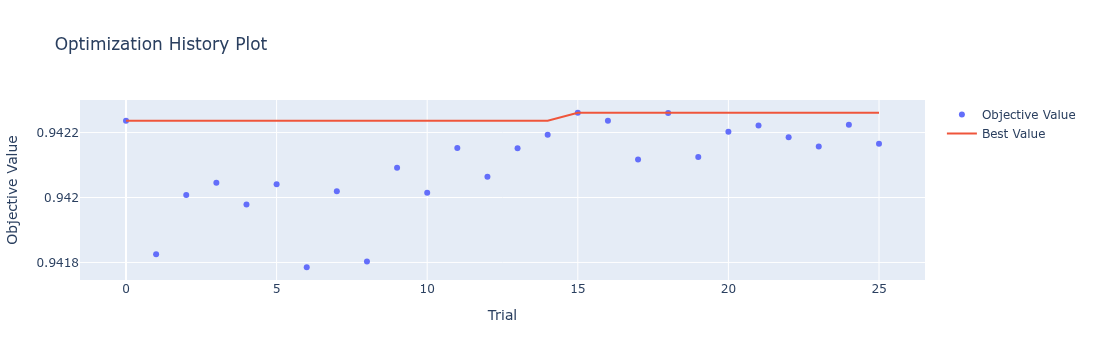

In [6]:
try:
    fig = optuna.visualization.plot_optimization_history(study)
    fig.show()
except NameError:
    print("Optuna wasn't run")

## 5. Model Training & Multi-Seed Blending

In [7]:
seeds = setup.seed()
oof_probs = np.zeros((len(X), 2))
test_probs = np.zeros((len(X_test), 2))
filled_mask = np.ones(len(X), dtype=bool)

models = []
eval_results = []
seed_scores = {}

base_params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'device': 'gpu' if setup.use_gpu() else 'cpu',
    'n_estimators': 2000,
    'verbose': -1,
    **best_params
}

for current_seed in seeds:
    print(f'\n--- Training LightGBM across 5 Folds with Seed {current_seed} ---')
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=current_seed)
    seed_oof = np.zeros(len(X))
    
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, y_tr = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
        
        model = lgb.LGBMClassifier(**base_params, random_state=current_seed)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )
        
        val_pred_prob = model.predict_proba(X_val)
        seed_oof[val_idx] = val_pred_prob[:, 1]
        
        oof_probs[val_idx, 0] += val_pred_prob[:, 0] / len(seeds)
        oof_probs[val_idx, 1] += val_pred_prob[:, 1] / len(seeds)
        
        test_pred_prob = model.predict_proba(X_test)
        test_probs[:, 0] += test_pred_prob[:, 0] / (len(seeds) * 5)
        test_probs[:, 1] += test_pred_prob[:, 1] / (len(seeds) * 5)
        
        models.append(model)
        eval_results.append(model.evals_result_)
        
        fold_auc = roc_auc_score(y_val, val_pred_prob[:, 1])
        print(f'Seed {current_seed} | Fold {fold+1} ROC AUC: {fold_auc:.6f}')
        
    seed_auc = roc_auc_score(y, seed_oof)
    seed_scores[current_seed] = seed_auc
    print(f'>>> Seed {current_seed} OOF ROC AUC: {seed_auc:.6f}')

print('\n==========================================')
for s, score in seed_scores.items():
    print(f'Seed {s:<5} OOF ROC AUC: {score:.6f}')
overall_auc = roc_auc_score(y, oof_probs[:, 1])
print('------------------------------------------')
print(f'Overall Multi-Seed OOF ROC AUC: {overall_auc:.6f}')
print('==========================================')



--- Training LightGBM across 5 Folds with Seed 10301 ---
Seed 10301 | Fold 1 ROC AUC: 0.941046
Seed 10301 | Fold 2 ROC AUC: 0.942431
Seed 10301 | Fold 3 ROC AUC: 0.942608
Seed 10301 | Fold 4 ROC AUC: 0.941649
Seed 10301 | Fold 5 ROC AUC: 0.943333
>>> Seed 10301 OOF ROC AUC: 0.942204

--- Training LightGBM across 5 Folds with Seed 42 ---
Seed 42 | Fold 1 ROC AUC: 0.940887
Seed 42 | Fold 2 ROC AUC: 0.942182
Seed 42 | Fold 3 ROC AUC: 0.943482
Seed 42 | Fold 4 ROC AUC: 0.942720
Seed 42 | Fold 5 ROC AUC: 0.942131
>>> Seed 42 OOF ROC AUC: 0.942275

--- Training LightGBM across 5 Folds with Seed 2026 ---
Seed 2026 | Fold 1 ROC AUC: 0.941910
Seed 2026 | Fold 2 ROC AUC: 0.941407
Seed 2026 | Fold 3 ROC AUC: 0.943474
Seed 2026 | Fold 4 ROC AUC: 0.942415
Seed 2026 | Fold 5 ROC AUC: 0.942147
>>> Seed 2026 OOF ROC AUC: 0.942262

--- Training LightGBM across 5 Folds with Seed 777 ---
Seed 777 | Fold 1 ROC AUC: 0.943107
Seed 777 | Fold 2 ROC AUC: 0.942587
Seed 777 | Fold 3 ROC AUC: 0.941493
Seed 777 

## 6. Performance Visualization

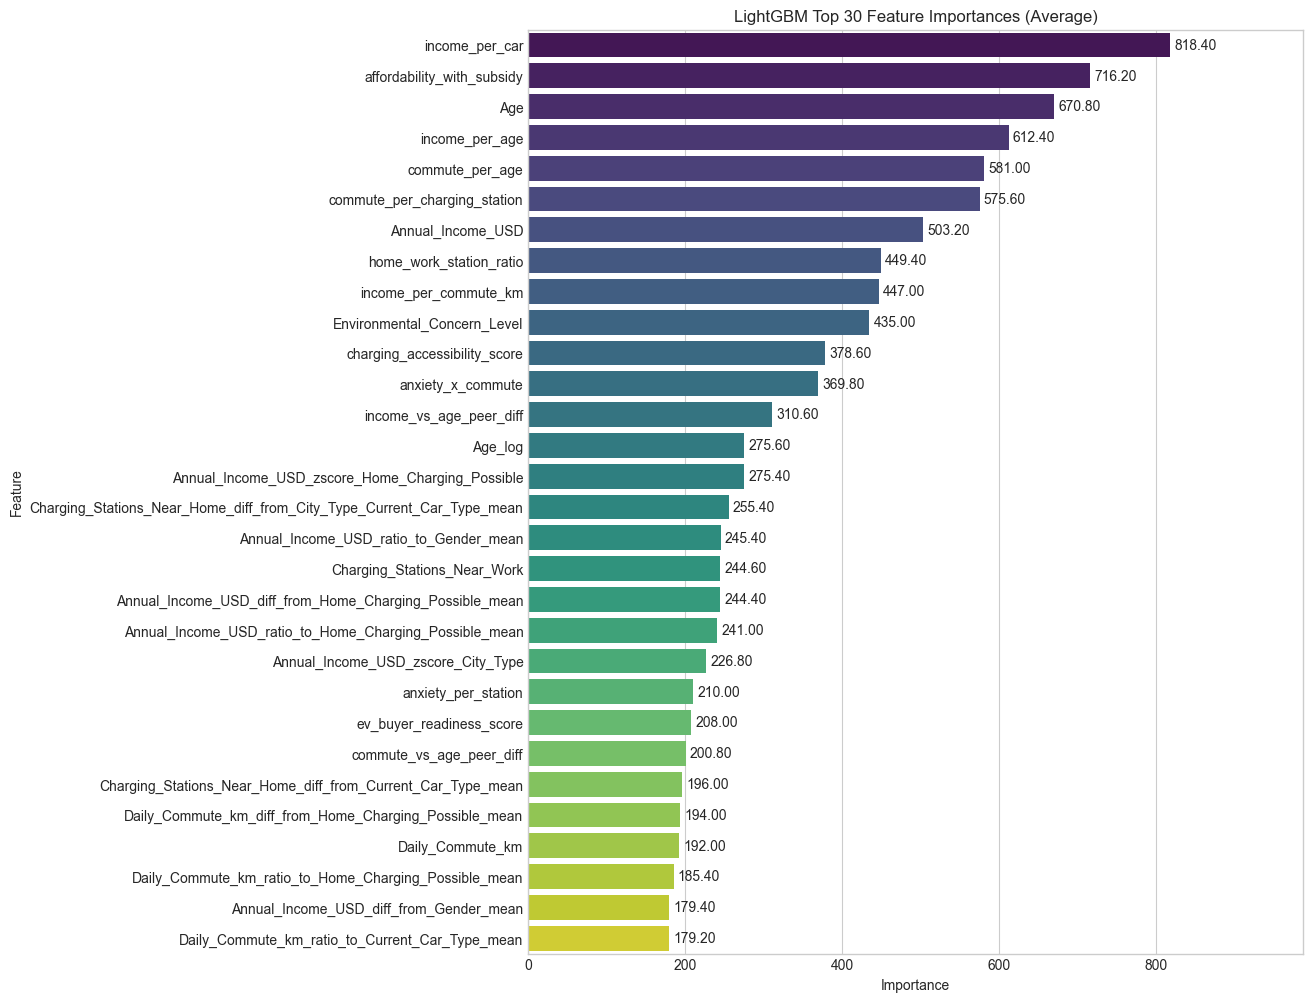

<Figure size 800x600 with 0 Axes>

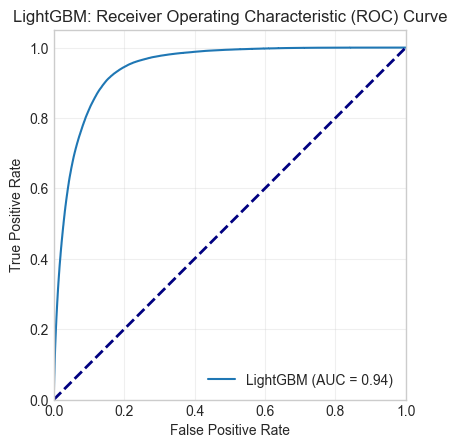

Confusion matrix, without normalization


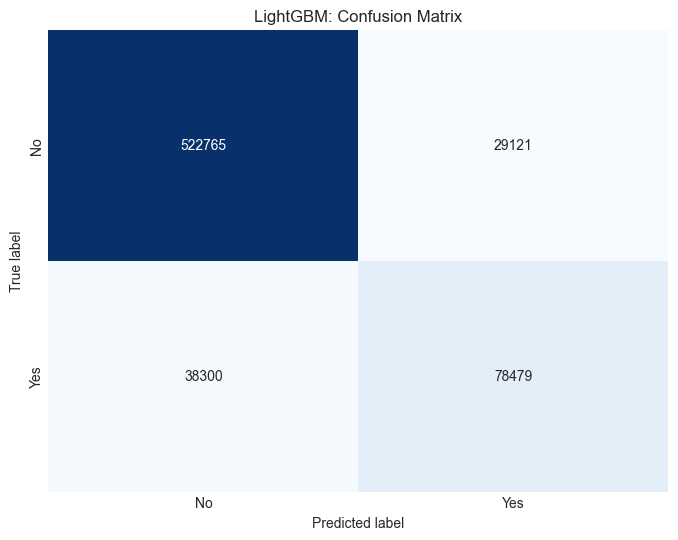

In [8]:
mviz = ModelVisualizer(model_name='LightGBM')
mviz.plot_feature_importance(models[:5], show_values=True)
mviz.plot_roc_curve(y_true=y, y_score=oof_probs[:, 1])

y_pred_class = (oof_probs[:, 1] >= 0.5).astype(int)
mviz.plot_confusion_matrix(y_true=y, y_pred=y_pred_class, classes=['No', 'Yes'])

## 7. Export Submission & Predictions

In [9]:
submission_df = setup.read_dataset('submission')
submission_df[TARGET] = test_probs[:, 1]
submission_df.to_csv('submission.csv', index=False)
print('Saved submission.csv successfully!')

setup.save_probabilities('lgb', oof_probs, train_ids, y, filled_mask, test_probs, test_ids)

Saved submission.csv successfully!
Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
